# A Hands-On Introduction to Brain Signals with MNE-Python

*An introduction to EEG/MEG analysis for readers familiar with data analysis but with limited prior exposure to neuroscience.*

The material is organised around the early chapters of **Rao, *Brain-Computer Interfacing: An Introduction*** (Cambridge, 2013) — specifically Part I (basic neuroscience, recording, signal processing) and the opening of Part II (Building a BCI). Coverage is selective rather than exhaustive: the goal is to establish enough intuition to navigate the rest of the MNE tutorial gallery independently.

## Table of contents

1. **Introduction to neuroscience** — Fundamental concepts required to understand the biophysical origin of EEG and MEG signals.
2. **Loading and inspection of a real dataset** — The MNE *sample* dataset, containing combined MEG, EEG and trigger channels recorded during an audio-visual experiment.
3. **Time-domain exploration** — Signal visualisation, channel types, sampling rate, and reference electrodes.
4. **Frequency-domain exploration** — The canonical brain rhythms (α, β, γ…) and their manifestation in the power spectrum.
5. **Filtering** — The role of band-pass and notch filters in signal preparation.
6. **Events and epochs** — Segmentation of continuous recordings around stimulus markers.
7. **Evoked responses (ERPs)** — The averaging technique that renders low-amplitude brain signals detectable.
8. **Artifacts** — Identification of ocular, cardiac and muscular contamination, with an introduction to Independent Component Analysis.

All examples run on the MNE **sample dataset**, which is downloaded automatically on first use (~1.5 GB). Subsequent notebooks in this series may extend the material to source localisation, connectivity analysis, and BCI-style decoding.

## Conventions

- 📖 **Theory cells** are short markdown explanations providing the conceptual background.
- 🧪 **Code cells** contain executable examples; running them and inspecting the output is essential.
- ❓ **Exercises** at the end of sections suggest small modifications that consolidate the concept.

Dense passages may be skipped on first reading and revisited later once the practical material has been assimilated.

## 1. Setup

The notebook requires Python 3.9 or later together with MNE-Python. The following installation command covers all dependencies used below:

```bash
pip install "mne[full]" matplotlib numpy scipy
```

The `[full]` extra installs optional dependencies (scikit-learn, nibabel, dipy, and others), which become useful in more advanced workflows but are not strictly required here. A minimal `pip install mne` is sufficient for this notebook.

In [5]:
!pip install "mne[full]" matplotlib numpy scipy PyQt5 ipympl

In [6]:
# Core scientific stack
import numpy as np
import matplotlib.pyplot as plt

# MNE-Python — the main library for M/EEG analysis in Python
import mne
from mne.datasets import sample

# Inline matplotlib backend. Use %matplotlib qt for interactive windows.
%matplotlib inline
plt.rcParams["figure.dpi"] = 100

print("MNE version:", mne.__version__)

MNE version: 1.12.0


> **Note.** Interactive plot windows (with zoom and channel scrolling) require `%matplotlib qt` (with PyQt installed) or `%matplotlib widget` (with `ipympl` installed). The inline backend is adequate for a first reading.

## 2. Introduction to neuroscience

Before any data is loaded, it is worth establishing what EEG and MEG recordings actually measure. This section contains no code and provides a minimal briefing on the biophysical origin of the signals.

### 2.1 Neurons and action potentials

The human brain contains approximately 86 billion **neurons**. Each neuron is composed of:

- a **cell body** (soma),
- **dendrites** — branching input structures that receive signals from other neurons,
- an **axon** — a single output fibre along which the neuron's signal propagates.

When sufficient excitatory input accumulates at the dendrites, the neuron generates an **action potential** (or "spike"): a rapid (≈ 1 ms) voltage pulse that travels along the axon. Action potentials are approximately all-or-none events. Information is encoded in their timing and rate, not in their amplitude.

### 2.2 Synapses and postsynaptic potentials

At the junction between an axon terminal and the dendrite of the next neuron lies a narrow cleft called a **synapse**. The arrival of an action potential triggers the release of neurotransmitters, which cross the cleft and produce a small, slower voltage change on the receiving side — a **postsynaptic potential (PSP)**. Postsynaptic potentials differ from action potentials in three respects:

- amplitude is smaller (millivolts rather than tens of millivolts),
- duration is longer (tens to hundreds of milliseconds),
- they are *graded* rather than all-or-none.

This distinction is crucial: **EEG and MEG do not resolve individual action potentials**. The measured signal reflects the *summed postsynaptic potentials of large, synchronously active neural populations* — principally cortical pyramidal neurons, whose dendritic arborisation is aligned perpendicular to the cortical surface.

### 2.3 What EEG and MEG measure

| Modality | Measurement | Spatial resolution | Temporal resolution |
|---|---|---|---|
| **EEG** | Electric potential on the scalp (μV), produced by synchronised PSPs | Poor (cm); the skull introduces substantial blurring | Excellent (ms) |
| **MEG** | Magnetic field just outside the head (fT), produced by the same currents | Better than EEG (mm–cm) | Excellent (ms) |
| **fMRI** | Blood oxygenation — an *indirect* correlate of neural activity | Good (mm) | Poor (seconds) |
| **ECoG / iEEG** | Electrodes placed on or within the cortex | Excellent (mm) | Excellent (ms) |

The present notebook focuses on **EEG** (with incidental reference to MEG, since the sample dataset contains both). Both modalities are non-invasive, time-resolved, and relatively inexpensive — characteristics that explain the predominance of EEG in consumer-grade BCI hardware.

### 2.4 Brain rhythms

Populations of cortical neurons display characteristic oscillatory activity. The canonical frequency bands are:

- **Delta (δ)** — 0.5–4 Hz, dominant during deep sleep;
- **Theta (θ)** — 4–8 Hz, associated with drowsiness and memory processes;
- **Alpha (α)** — 8–13 Hz, prominent during relaxed wakefulness with eyes closed, strongest over occipital cortex;
- **Beta (β)** — 13–30 Hz, associated with active cognitive engagement and motor activity;
- **Gamma (γ)** — 30–100+ Hz, linked to attention and perceptual binding.

The alpha rhythm will be directly observable in the data analysed below.

## 3. Loading the sample dataset

MNE-Python ships with a reference **sample dataset**: a single session from one subject, combining MEG and EEG during a simple audio-visual task. It serves a role comparable to MNIST in machine learning. The first call to `sample.data_path()` downloads approximately 1.5 GB into `~/mne_data/`; subsequent calls use the cached copy.

In [7]:
# First call downloads and caches; subsequent calls are instantaneous.
data_path = sample.data_path()
raw_fname = data_path / "MEG" / "sample" / "sample_audvis_filt-0-40_raw.fif"

raw = mne.io.read_raw_fif(raw_fname, preload=True)
raw

Opening raw data file /Users/marta/mne_data/MNE-sample-data/MEG/sample/sample_audvis_filt-0-40_raw.fif...
    Read a total of 4 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
        Average EEG reference (1 x 60)  idle
    Range : 6450 ... 48149 =     42.956 ...   320.665 secs
Ready.
Reading 0 ... 41699  =      0.000 ...   277.709 secs...


<Raw | sample_audvis_filt-0-40_raw.fif, 376 x 41700 (277.7 s), ~122.8 MiB, data loaded>

`Raw` is the MNE container for **continuous** recordings, as distinct from data already segmented into trials. The object's representation above reports the number of channels, the sampling frequency, the recording duration, and any filters previously applied to the file (this file has been pre-filtered to 0–40 Hz, as indicated by its name).

In [8]:
# The .info attribute is a dict-like object holding all metadata.
# Every MNE operation consults this structure; one complete reading is recommended.
print(raw.info)

<Info | 15 non-empty values
 bads: 2 items (MEG 2443, EEG 053)
 ch_names: MEG 0113, MEG 0112, MEG 0111, MEG 0122, MEG 0123, MEG 0121, MEG ...
 chs: 204 Gradiometers, 102 Magnetometers, 9 Stimulus, 60 EEG, 1 EOG
 custom_ref_applied: False
 dev_head_t: MEG device -> head transform
 dig: 146 items (3 Cardinal, 4 HPI, 61 EEG, 78 Extra)
 file_id: 4 items (dict)
 highpass: 0.1 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 lowpass: 40.0 Hz
 meas_date: 2002-12-03 19:01:10 UTC
 meas_id: 4 items (dict)
 nchan: 376
 projs: PCA-v1: off, PCA-v2: off, PCA-v3: off, Average EEG reference: off
 sfreq: 150.2 Hz
>


### 3.1 Structure of `raw.info`

The most important fields are the following:

- **`sfreq`** — sampling frequency in Hz. The value here is 150 Hz (downsampled from the original 600 Hz). The Nyquist frequency, `sfreq / 2` = 75 Hz, is the upper bound on frequencies that can be reliably represented in the signal.
- **`ch_names`** — the list of channel labels.
- **`chs`** — per-channel metadata including type, position, unit, and calibration factor.
- **`bads`** — channels flagged as defective. Empty in this dataset, but rarely empty in real recordings.
- **`projs`** — Signal-Space Projection (SSP) vectors used to suppress physiological noise sources such as the heartbeat.

In [9]:
print("Sampling frequency:", raw.info["sfreq"], "Hz")
print("Recording duration:", raw.times[-1], "seconds")
print("Number of channels:", len(raw.ch_names))
print("First 10 channel names:", raw.ch_names[:10])

Sampling frequency: 150.15374755859375 Hz
Recording duration: 277.7086864497205 seconds
Number of channels: 376
First 10 channel names: ['MEG 0113', 'MEG 0112', 'MEG 0111', 'MEG 0122', 'MEG 0123', 'MEG 0121', 'MEG 0132', 'MEG 0133', 'MEG 0131', 'MEG 0143']


In [10]:
# Channel counts by type.
from collections import Counter
ch_types = raw.get_channel_types()
print(Counter(ch_types))

Counter({'grad': 204, 'mag': 102, 'eeg': 60, 'stim': 9, 'eog': 1})


The file therefore contains:

- **MEG channels**: 102 magnetometers and 204 gradiometers (306 total), consistent with the Elekta/MEGIN sensor layout;
- **60 EEG** channels;
- **EOG** (electro-oculogram), used to record eye movements for artifact detection;
- **STIM** (trigger channel), recording the timing of stimulus delivery.

The subsequent analysis concentrates on the EEG channels and uses the STIM channel to recover event markers.

## 4. Sensor positions

EEG electrodes are placed on the scalp according to standardised systems — most commonly the **international 10–20 system** or its denser variants, 10–10 and 10–5. Each electrode label encodes its approximate location:

- the first letter indicates the cortical lobe (F = frontal, C = central, P = parietal, O = occipital, T = temporal);
- the number specifies position (odd values lie on the left, even values on the right, and `z` denotes the midline).

The sample dataset uses 60 electrodes from the extended 10–20 system.

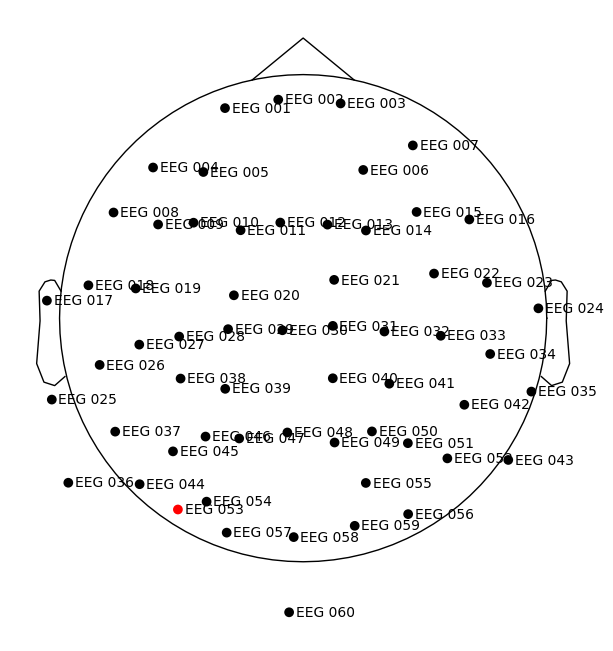

In [11]:
# Schematic top-down view of the EEG montage.
fig = raw.plot_sensors(ch_type="eeg", show_names=True)

The layout shows the characteristic grid: `Fp1/Fp2` at the front, `O1/O2` at the back, and `Cz` at the vertex. Knowledge of electrode position is essential for signal interpretation: brain rhythms originate from specific cortical regions — alpha predominates over occipital sites, whereas motor imagery generates signatures over central sites — so the channel location directly constrains the expected content of the recording.

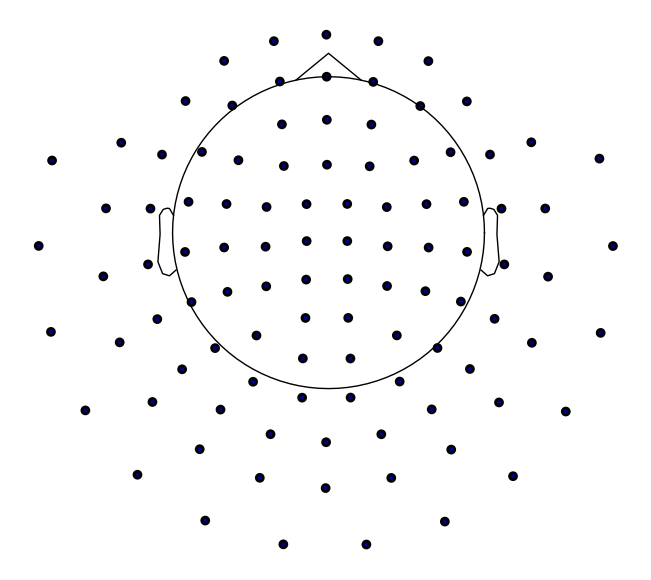

In [12]:
# MEG sensors are arranged on a helmet, not on the scalp.
fig = raw.plot_sensors(ch_type="mag")

❓ **Exercise.** The call `raw.plot_sensors(kind='3d', ch_type='eeg')` produces a three-dimensional rendering of the electrodes on a head model. This provides a more accurate sense of curvature than the schematic projection.

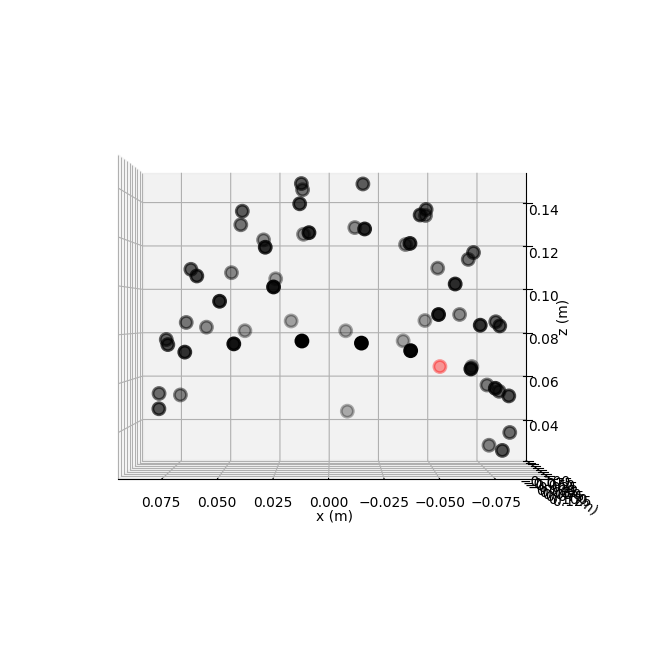

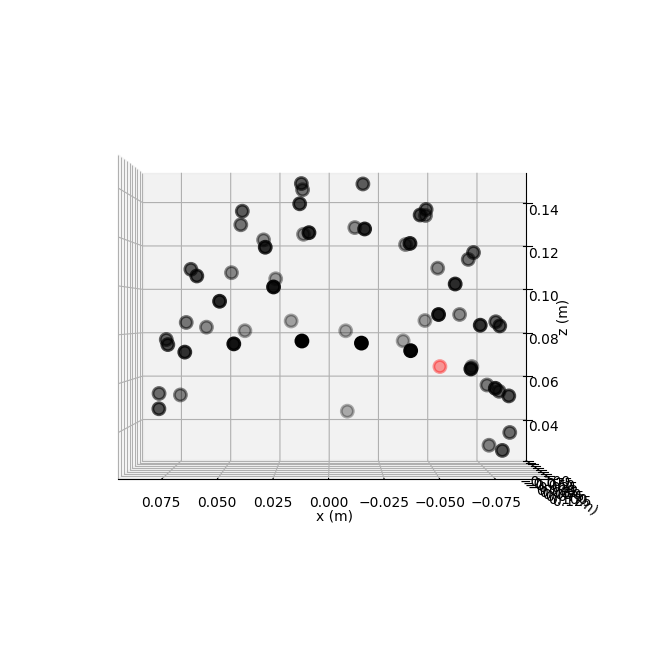

In [13]:
raw.plot_sensors(kind='3d', ch_type='eeg')

## 5. Visualisation of the raw signal

The first step in any M/EEG analysis is **visual inspection** of the continuous recording. Despite the availability of automated methods, trained visual inspection remains the most reliable artifact detector.

In [14]:
# Plot options:
# - duration: number of seconds displayed per page
# - n_channels: number of traces shown simultaneously
# - start: initial time in seconds
fig = raw.copy().pick("eeg").plot(duration=5, n_channels=20, start=10, scalings=dict(eeg=50e-6))

Using qt as 2D backend.


Channels marked as bad:
['EEG 053']


Several features of the display merit attention:

- Signals fluctuate around zero: they are **AC**, not DC. EEG electrodes measure *potential differences* between pairs of points, so an absolute zero does not exist in the usual sense.
- Amplitudes are on the order of **tens of microvolts** — approximately five orders of magnitude smaller than a standard AA battery. This constraint drives the demand for extremely low-noise acquisition hardware.
- The traces appear noisy but are not random: rhythmic components can often be identified by inspection alone.

### 5.1 Direct access to the signal array

For custom analyses, the numerical signal can be obtained directly. The method `raw.get_data()` returns an array of shape `(n_channels, n_times)`.

In [15]:
# Extract two seconds from channel 'EEG 001'.
picks = mne.pick_channels(raw.ch_names, include=["EEG 001"])
data, times = raw[picks, int(10 * raw.info["sfreq"]):int(12 * raw.info["sfreq"])]

print("Shape:", data.shape)     # (1 channel, N samples)
print("First 5 samples (V):", data[0, :5])

Shape: (1, 300)
First 5 samples (V): [-1.63971604e-05 -1.63190460e-05 -1.14891379e-05 -8.25968619e-06
 -8.51543090e-06]


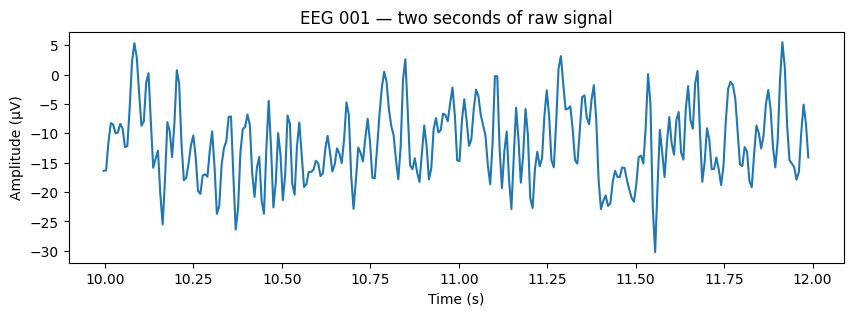

In [16]:
# Manual plot, to demonstrate the underlying representation.
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(times, data[0] * 1e6)   # convert V to μV
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (μV)")
ax.set_title("EEG 001 — two seconds of raw signal")
plt.show()

## 6. Frequency-domain analysis

A single EEG trace bears little visible structure. A complementary representation — the **power spectral density (PSD)** — addresses the question *which frequencies are present, and with what amplitude?* Structure absent from the time-domain view becomes apparent in this representation.

### 6.1 Fourier decomposition

Any signal can be expressed as a sum of sine and cosine components at different frequencies. The **Fourier transform** assigns an amplitude (and phase) to each component. For discrete sampled data the appropriate operation is the **Discrete Fourier Transform (DFT)**, typically computed through the **Fast Fourier Transform (FFT)** algorithm.

MNE wraps `scipy.signal.welch` and computes the PSD directly; a manual implementation is not required.

Effective window size : 13.639 (s)
Plotting power spectral density (dB=True).


/opt/anaconda3/envs/mne/lib/python3.11/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


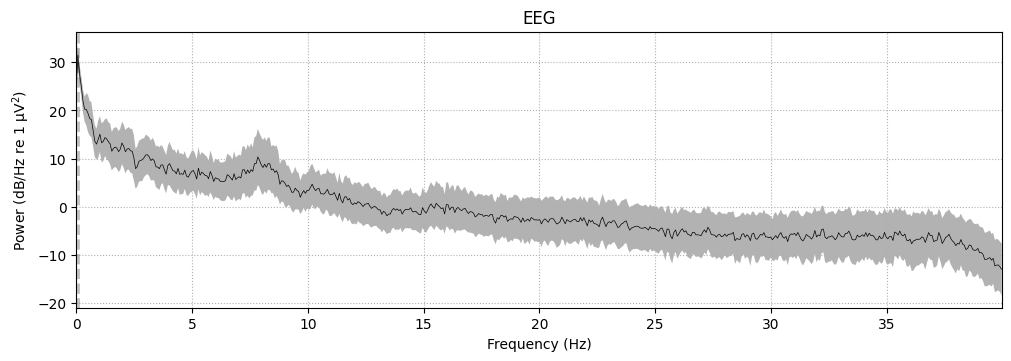

In [17]:
# PSD computed across the full recording, EEG channels only, up to 40 Hz.
spectrum = raw.compute_psd(picks="eeg", fmax=40)
fig = spectrum.plot(average=True)       # average across channels

The curve represents power averaged across all EEG electrodes. Three features warrant attention:

- **1/f slope.** Background brain activity exhibits a characteristic "pink-noise" spectrum — power decreases with frequency. This is the generic background against which rhythms are detected.
- **Departures from the slope correspond to rhythms.** A bump near 10 Hz is expected: this is the **alpha rhythm**, the most prominent EEG oscillation in awake adults, particularly pronounced when the eyes are closed.
- **A peak near 50 Hz** (or 60 Hz in North America) would indicate line-noise contamination from the electrical mains. The present file is pre-filtered at 40 Hz, so this artifact is not visible.

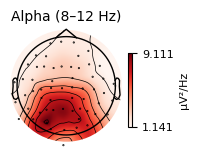

In [18]:
# Spatial distribution of alpha-band power across the scalp.
fig = spectrum.plot_topomap(bands={"Alpha (8–12 Hz)": (8, 12)}, ch_type="eeg")

The alpha rhythm is maximal over **posterior/occipital** sites, in agreement with the canonical description. The high-amplitude posterior region corresponds to the generator of the alpha rhythm, located approximately in the calcarine cortex.

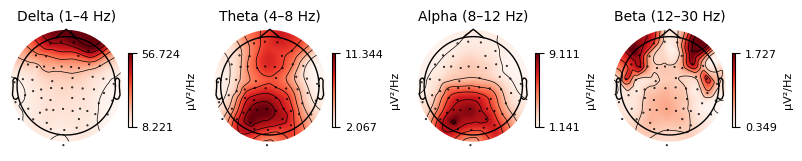

In [19]:
# Simultaneous comparison of the canonical frequency bands.
bands = {
    "Delta (1–4 Hz)":   (1, 4),
    "Theta (4–8 Hz)":   (4, 8),
    "Alpha (8–12 Hz)":  (8, 12),
    "Beta (12–30 Hz)":  (12, 30),
}
fig = spectrum.plot_topomap(bands=bands, ch_type="eeg")

Each topography corresponds to a different frequency band. The expected patterns are:

- **Delta and theta**: frontal-midline hotspot, characteristic of low-arousal states and partly attributable to ocular artifacts;
- **Alpha**: posterior, reflecting the idling activity of the visual system;
- **Beta**: central and parietal, with overall lower amplitude.

A topographic map is, methodologically, a scatter of electrode positions coloured by a scalar value and spatially interpolated. MNE performs the operation automatically, but the principle is straightforward.

❓ **Exercise.** Compute the PSD on a single occipital channel (e.g. `"EEG 059"`) using `raw.compute_psd(picks=['EEG 059'], fmax=40).plot()`. The alpha peak should be more pronounced than in the channel-average plot.

Effective window size : 13.639 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/envs/mne/lib/python3.11/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


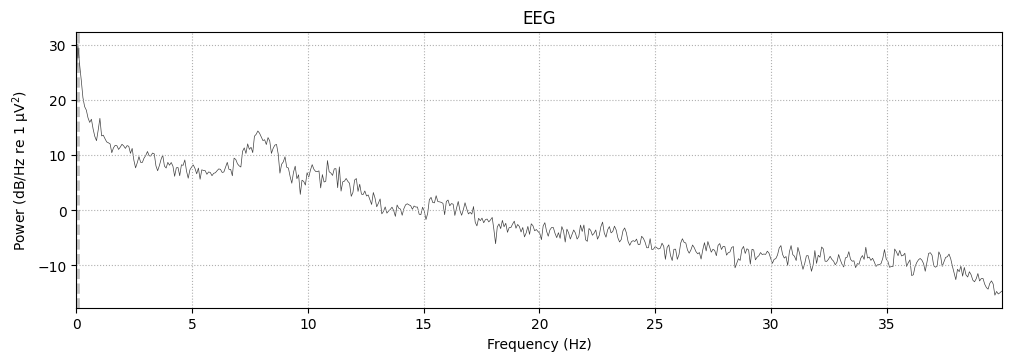

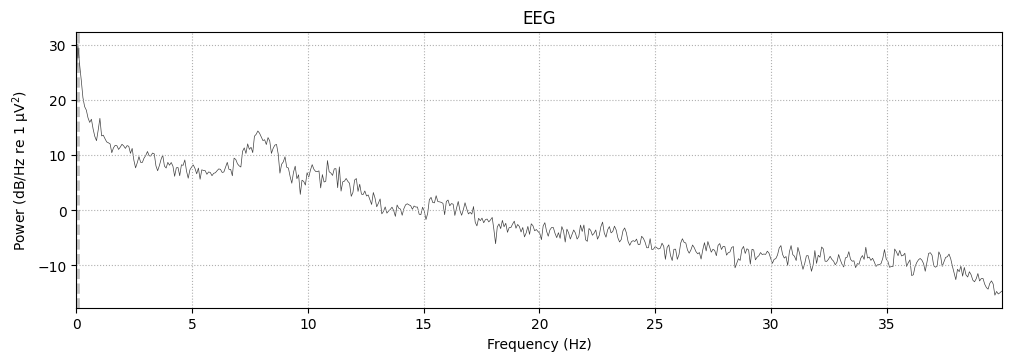

In [20]:
raw.compute_psd(picks=['EEG 059'], fmax=40).plot()

## 7. Filtering

Raw recordings contain a mixture of signals: brain activity, slow drifts, muscle activity, line noise, and mechanical disturbances. **Filtering** retains the frequency band of interest while attenuating the remainder.

Three filter types are used routinely:

| Filter | Retains | Typical use |
|---|---|---|
| **High-pass** | frequencies *above* a cutoff | removal of slow drifts (e.g. > 0.1 Hz) |
| **Low-pass** | frequencies *below* a cutoff | removal of high-frequency noise (e.g. < 40 Hz) |
| **Band-pass** | a frequency range | combined high- and low-pass, e.g. 1–40 Hz |
| **Notch** | removes a narrow band | suppression of 50/60 Hz line noise |

By default MNE applies zero-phase FIR filters. A salient property of this design is that the filter is applied forward and backward, avoiding phase distortion at the cost of edge artifacts near the start and end of the recording.

In [21]:
# Load the *unfiltered* version of the sample data, for demonstration.
raw_unfilt_fname = data_path / "MEG" / "sample" / "sample_audvis_raw.fif"
raw_unfilt = mne.io.read_raw_fif(raw_unfilt_fname, preload=True)
raw_unfilt

Opening raw data file /Users/marta/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...


<Raw | sample_audvis_raw.fif, 376 x 166800 (277.7 s), ~481.7 MiB, data loaded>

Effective window size : 3.410 (s)
Plotting power spectral density (dB=True).


/opt/anaconda3/envs/mne/lib/python3.11/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


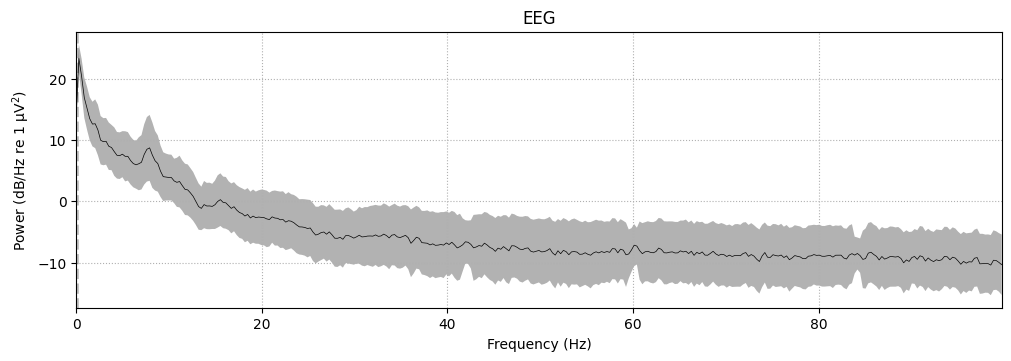

In [22]:
# PSD before filtering — a pronounced 60 Hz line-noise peak is expected (US mains).
spec_unfilt = raw_unfilt.compute_psd(picks="eeg", fmax=100)
fig = spec_unfilt.plot(average=True)

The peak near 60 Hz corresponds to **line noise**; the equivalent peak occurs at 50 Hz in European recordings. Contamination from electrical mains is nearly universal — originating from electronics, lighting, displays, and neighbouring equipment. Two remediation strategies are available:

1. **Notch filter** at 60 Hz (and harmonics);
2. **Low-pass filter** below 60 Hz, when gamma-band activity is not required.

Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 3965 samples (6.602 s)

Effective window size : 3.410 (s)
Plotting power spectral density (dB=True).


/opt/anaconda3/envs/mne/lib/python3.11/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


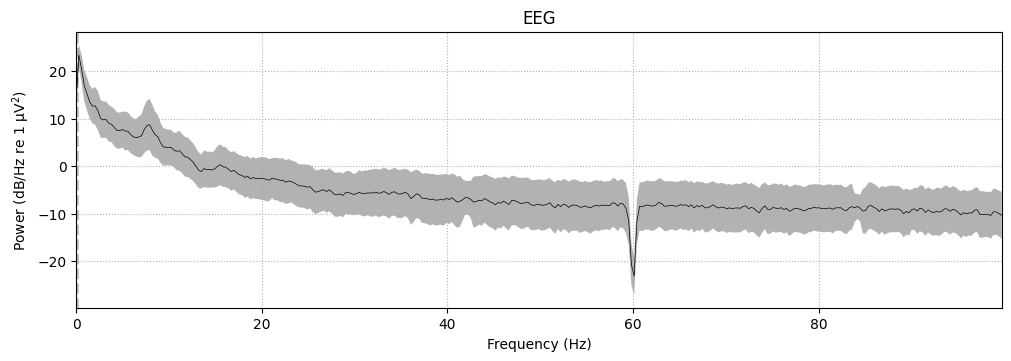

In [23]:
# Notch filter at 60 Hz and its harmonic at 120 Hz.
raw_notched = raw_unfilt.copy().notch_filter(freqs=[60, 120], picks="eeg")
spec_notched = raw_notched.compute_psd(picks="eeg", fmax=100)
fig = spec_notched.plot(average=True)

The line-noise peak is now suppressed. A band-pass filter is subsequently applied to restrict the signal to the canonical 1–40 Hz range employed in most ERP analyses.

Filtering a subset of channels. The highpass and lowpass values in the measurement info will not be updated.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1983 samples (3.302 s)

Effective window size : 3.410 (s)
Plotting power spectral density (dB=True).


/opt/anaconda3/envs/mne/lib/python3.11/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


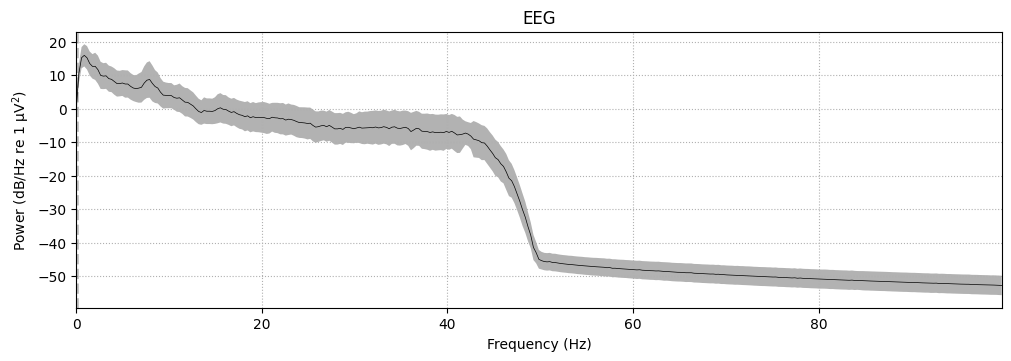

In [24]:
raw_band = raw_notched.copy().filter(l_freq=1.0, h_freq=40.0, picks="eeg")
spec_band = raw_band.compute_psd(picks="eeg", fmax=100)
fig = spec_band.plot(average=True)

Observations on the resulting spectrum:

- below 1 Hz — attenuated (slow drifts removed);
- above 40 Hz — attenuated (high-frequency noise removed);
- the 1/f slope and alpha bump are now cleanly visible.

**Practical rule.** The choice of band-pass depends on the question under investigation. Standard ERP analysis uses 0.1–40 Hz; motor-imagery BCIs use 8–30 Hz (covering the μ and β bands); sleep staging uses 0.3–35 Hz; high-gamma ECoG analyses use 70–170 Hz.

### 7.1 Filter effects in the time domain

The same recording segment can be compared before and after the band-pass operation.

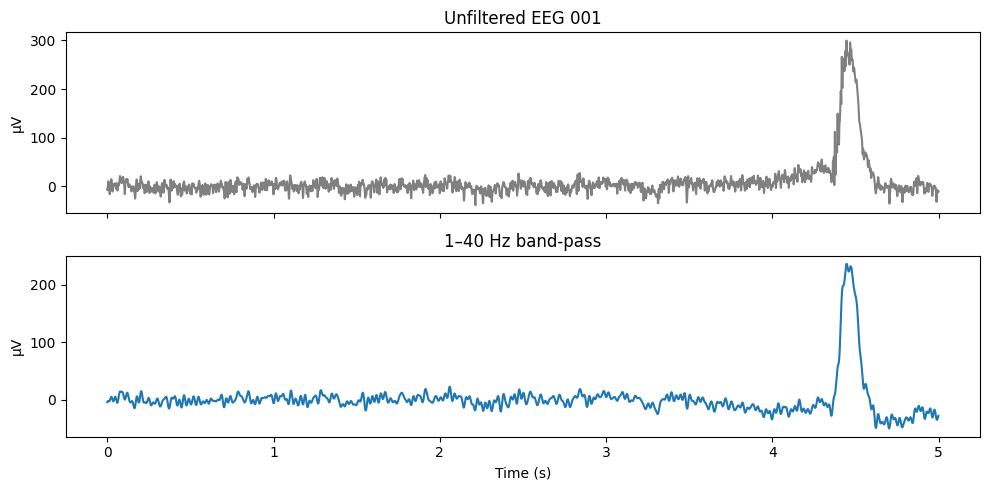

In [25]:
# Single channel, five-second window.
pick = raw.ch_names.index("EEG 001")
sfreq = raw_unfilt.info["sfreq"]
start, stop = int(10 * sfreq), int(15 * sfreq)

unfiltered = raw_unfilt.get_data(picks=[pick])[0, start:stop]
filtered = raw_band.get_data(picks=[pick])[0, start:stop]
t = np.arange(unfiltered.size) / sfreq

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(t, unfiltered * 1e6, color="gray")
axes[0].set_title("Unfiltered EEG 001")
axes[0].set_ylabel("μV")
axes[1].plot(t, filtered * 1e6, color="C0")
axes[1].set_title("1–40 Hz band-pass")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("μV")
plt.tight_layout()
plt.show()

The filtered trace has lost both the slow drift (the unfiltered signal wanders up and down over several seconds, whereas the filtered signal remains centred on zero) and the high-frequency jitter. The surviving rhythmic content in the middle band constitutes the signal of interest.

## 8. Events and epochs

Brain signals are noisy. A single occurrence of an evoked response is typically invisible in the ongoing EEG. The standard procedure is:

1. Present the stimulus many times;
2. Cut the recording into short **epochs** time-locked to each stimulus onset;
3. **Average** across epochs. Signal components that are phase-locked to the stimulus add constructively, while noise uncorrelated with the stimulus cancels.

The result is an **Evoked Response** or **Event-Related Potential (ERP)**. ERP components are labelled by polarity and latency in milliseconds (P100, N170, P300, N400, and others).

### 8.1 Event detection

The sample recording stores trigger codes on the stim channel `STI 014`, with an integer value marking each stimulus onset.

In [26]:
events = mne.find_events(raw, stim_channel="STI 014")
print("Events shape:", events.shape)    # (n_events, 3)
print("First 10 events:\n", events[:10])

Finding events on: STI 014
319 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
Events shape: (319, 3)
First 10 events:
 [[6994    0    2]
 [7086    0    3]
 [7192    0    1]
 [7304    0    4]
 [7413    0    2]
 [7506    0    3]
 [7612    0    1]
 [7709    0    4]
 [7810    0    2]
 [7916    0    3]]


Each row encodes `[sample_index, previous_value, new_value]`. The last column holds the **event code**. For the present experiment:

- `1` — auditory stimulus, left ear;
- `2` — auditory stimulus, right ear;
- `3` — visual stimulus, left visual field;
- `4` — visual stimulus, right visual field;
- `5` — smiley face (button-press trial);
- `32` — button press.

/var/folders/dy/w9xm150112nf0_dgql35gwfr0000gn/T/ipykernel_54455/2184266751.py:9: RuntimeWarning: event 5 missing from event_id will be ignored
  fig = mne.viz.plot_events(events, sfreq=raw.info["sfreq"],
/var/folders/dy/w9xm150112nf0_dgql35gwfr0000gn/T/ipykernel_54455/2184266751.py:9: RuntimeWarning: event 32 missing from event_id will be ignored
  fig = mne.viz.plot_events(events, sfreq=raw.info["sfreq"],


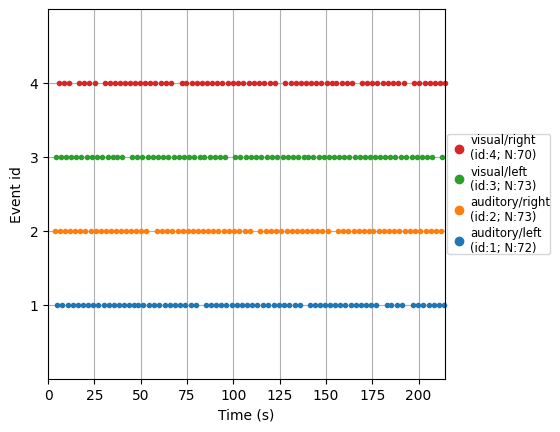

In [27]:
event_id = {
    "auditory/left":  1,
    "auditory/right": 2,
    "visual/left":    3,
    "visual/right":   4,
}

# Temporal distribution of events.
fig = mne.viz.plot_events(events, sfreq=raw.info["sfreq"],
                          first_samp=raw.first_samp, event_id=event_id)

### 8.2 Epoching

An **epoch** is a time window `[tmin, tmax]` centred on each event. Convention includes a short pre-stimulus interval (the baseline, used to correct for overall drift) and a longer post-stimulus interval.

In [28]:
epochs = mne.Epochs(
    raw,
    events,
    event_id=event_id,
    tmin=-0.2,                 # 200 ms before stimulus
    tmax=0.5,                  # 500 ms after
    baseline=(None, 0),        # subtract the mean of the pre-stimulus period
    preload=True,
    picks=["eeg", "eog"],      # retain EOG for later artifact rejection
    reject=dict(eeg=150e-6),   # drop epochs exceeding 150 μV (probable artifacts)
)
epochs

Not setting metadata
288 matching events found
Setting baseline interval to [-0.19979521315838786, 0.0] s
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Using data from preloaded Raw for 288 events and 106 original time points ...
    Rejecting  epoch based on EEG : ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 007']
1 bad epochs dropped


<Epochs | 287 events (all good), -0.2 – 0.499 s (baseline -0.2 – 0 s), ~17.1 MiB, data loaded,
 'auditory/left': 72
 'auditory/right': 72
 'visual/left': 73
 'visual/right': 70>

The `Epochs` object wraps a three-dimensional array of shape `(n_epochs, n_channels, n_times)`. MNE automatically discards epochs that exceed the `reject` threshold — a simple amplitude-based artifact rejection. Production pipelines generally rely on more sophisticated approaches (ICA is introduced in §10).

In [29]:
print("Data shape:", epochs.get_data().shape)
print("Trials per condition:")
for cond in event_id:
    print(f"  {cond}: {len(epochs[cond])}")

Data shape: (287, 61, 106)
Trials per condition:
  auditory/left: 72
  auditory/right: 72
  visual/left: 73
  visual/right: 70


## 9. Evoked responses

Averaging epochs belonging to the same condition yields an **Evoked** object. This operation is where the EEG ceases to look like noise and begins to reveal structure.

In [30]:
evoked_aud = epochs["auditory"].average()   # averages left and right auditory trials
evoked_vis = epochs["visual"].average()

print(evoked_aud)

<Evoked | '0.50 × auditory/left + 0.50 × auditory/right' (average, N=144), -0.1998 – 0.49949 s, baseline -0.199795 – 0 s, 60 ch, ~3.0 MiB>


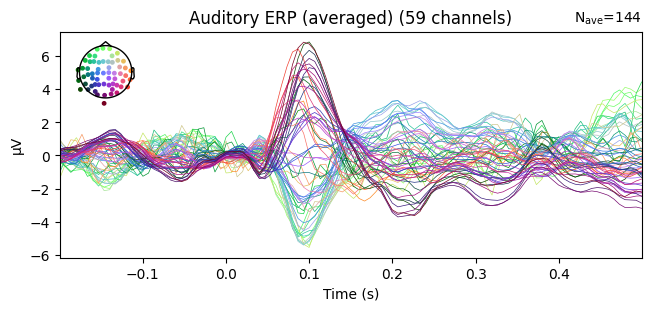

In [31]:
# Classical ERP display: one waveform per channel.
fig = evoked_aud.plot(spatial_colors=True, titles=dict(eeg="Auditory ERP (averaged)"))

A large negative deflection near **100 ms** post-stimulus dominates the plot: this is the **N100** (or N1) component, a canonical auditory evoked response generated in auditory cortex. A positive peak near **200 ms** — the **P200** — typically follows. Both components are sufficiently reliable to be used in clinical audiology.

The clean waveform visible here was imperceptible in any single trial. It emerges only after approximately 70 trials have been averaged together; this is the methodological justification for ERP analysis.

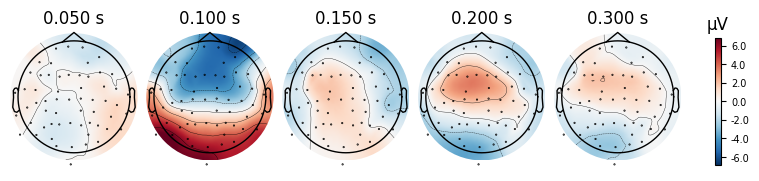

In [32]:
# Scalp topography at selected post-stimulus times.
fig = evoked_aud.plot_topomap(times=[0.05, 0.10, 0.15, 0.20, 0.30], ch_type="eeg")

At 100 ms the scalp map peaks bilaterally over temporal regions — a pattern consistent with sources in auditory cortex.

The corresponding visual condition exhibits different spatiotemporal characteristics:

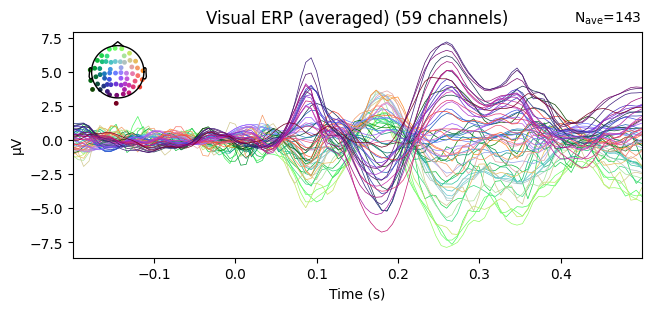

In [33]:
fig = evoked_vis.plot(spatial_colors=True, titles=dict(eeg="Visual ERP (averaged)"))

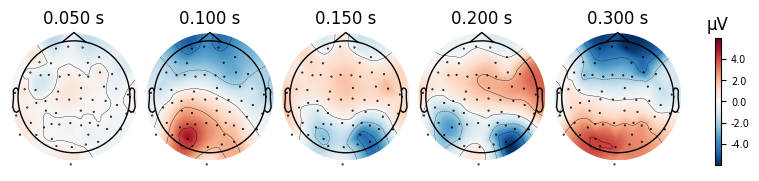

In [34]:
fig = evoked_vis.plot_topomap(times=[0.05, 0.10, 0.15, 0.20, 0.30], ch_type="eeg")

The timecourse and topography differ: activity is posterior (occipital) rather than temporal. The analytical procedure is identical; the underlying cortical system is not.

### 9.1 Condition comparison

A common analytical step is to overlay conditions in order to identify loci of differentiation.

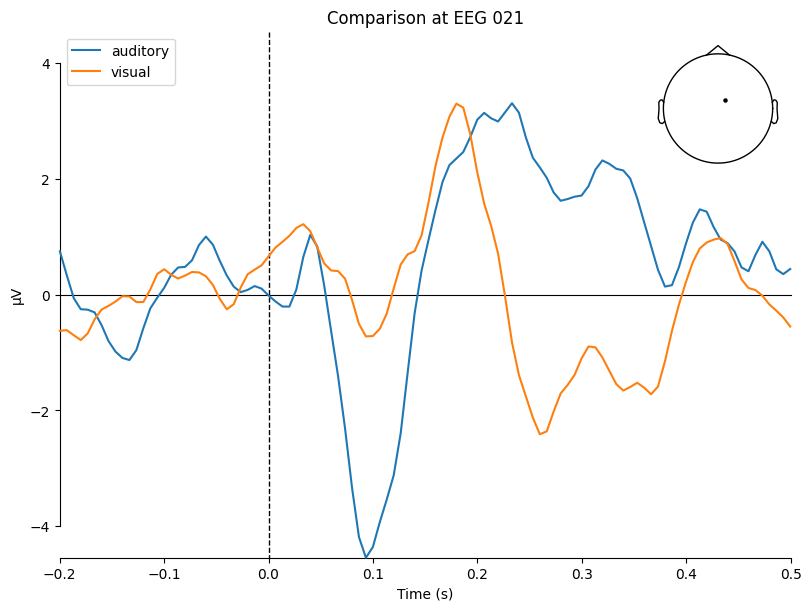

In [35]:
evokeds = dict(auditory=evoked_aud, visual=evoked_vis)

# One posterior channel selected for comparison.
fig = mne.viz.plot_compare_evokeds(
    evokeds, picks="EEG 021", title="Comparison at EEG 021"
)

❓ **Exercise.** Repeat the comparison at a posterior channel such as `'EEG 058'`. The visual condition is expected to produce a larger response at this location, consistent with the anatomy of the visual cortex.

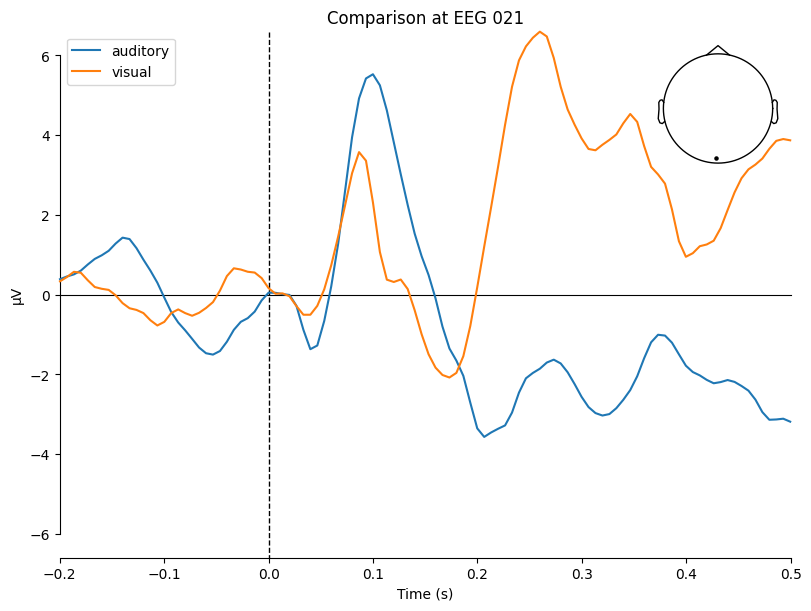

In [37]:
evokeds = dict(auditory=evoked_aud, visual=evoked_vis)

# One posterior channel selected for comparison.
fig = mne.viz.plot_compare_evokeds(
    evokeds, picks="EEG 058", title="Comparison at EEG 021"
)

## 10. Artifacts

A non-negligible fraction of any M/EEG signal originates from sources other than the brain. The most common contaminants are:

- **Eye blinks** — large frontal deflections, ~100–200 μV, readily visible;
- **Eye movements** — slow horizontal excursions; the EOG channel tracks them directly;
- **Heartbeat (ECG)** — regular ~1 Hz pulse, particularly prominent in MEG;
- **Muscle activity** — broadband high-frequency bursts originating from neck and jaw muscles.

### 10.1 Blink visualisation

The EOG channel allows blinks to be identified straightforwardly.

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1983 samples (3.302 s)

Using EOG channel: EOG 061
EOG channel index for this subject is: [60]
Filtering the data to remove DC offset to help distinguish blinks from saccades
Selecting channel EOG 061 for blink detection
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Low

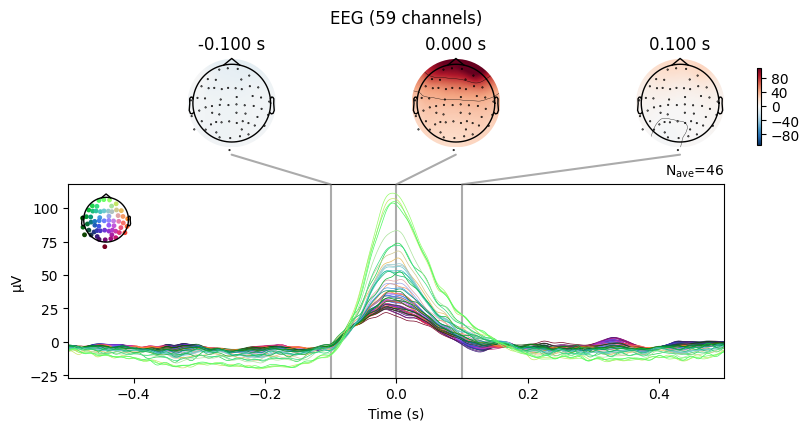

In [38]:
# Load unfiltered data; apply a mild band-pass for visualisation.
raw_art = raw_unfilt.copy().filter(1.0, 40.0).pick(["eeg", "eog"])

# Automatic blink detection.
eog_events = mne.preprocessing.find_eog_events(raw_art)
print(f"Detected {len(eog_events)} blink events")

# Epochs centred on blinks.
eog_epochs = mne.preprocessing.create_eog_epochs(raw_art)
fig = eog_epochs.average().plot_joint(times=[-0.1, 0, 0.1])

The large frontal deflection is a prototypical blink. Frontal EEG electrodes capture it strongly. Without prior cleaning, blinks that happen to be time-locked to stimulus presentations — a not-uncommon occurrence — would contaminate the ERP average.

### 10.2 Independent Component Analysis (ICA)

**Independent Component Analysis** assumes that the recorded signal is a linear mixture of statistically independent underlying sources, and attempts to recover the mixing. Applied to M/EEG, the procedure is:

1. Fit ICA on the continuous data;
2. Identify components whose properties match known artifacts (visually or automatically);
3. Zero out the identified components and reconstruct the cleaned signal.

A complete ICA decomposition requires a non-trivial fitting step. A minimal demonstration follows.

In [39]:
# raw_art is already band-pass filtered to 1-40 Hz.
# n_components: number of components to extract. A common heuristic matches the data rank.
ica = mne.preprocessing.ICA(n_components=15, random_state=42, max_iter="auto")
ica.fit(raw_art)
ica

Fitting ICA to data using 59 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 1.3s.


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,43 iterations on raw data (166800 samples)
ICA components,15
Available PCA components,59
Channel types,eeg
ICA components marked for exclusion,—


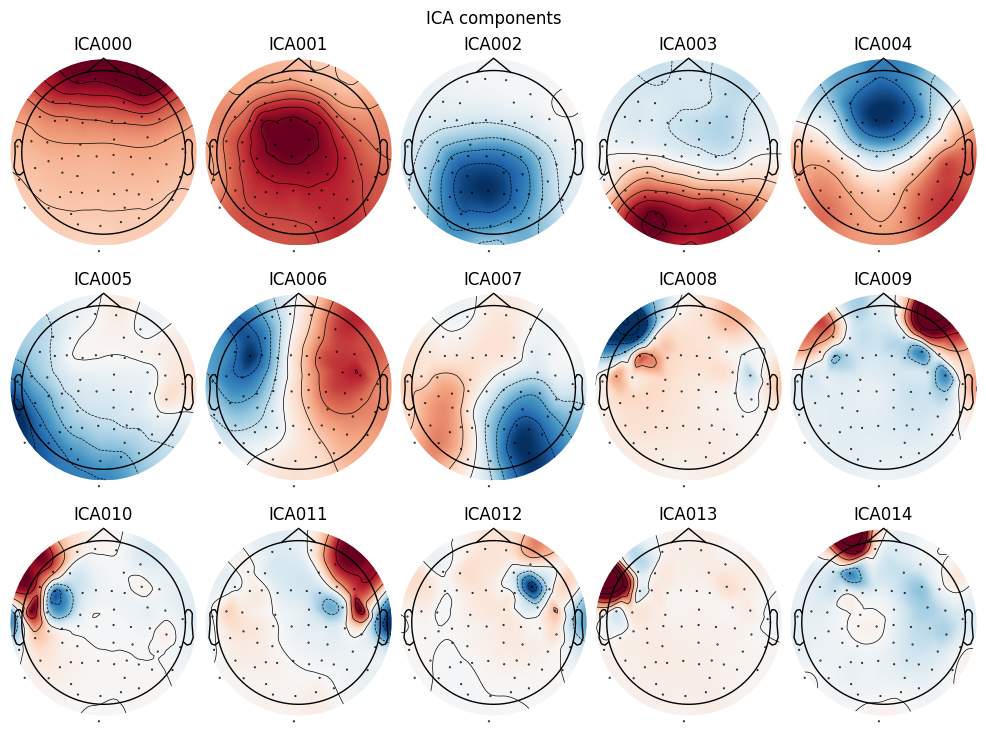

In [40]:
# Spatial pattern of each component.
fig = ica.plot_components()

Components with strongly frontal topographies are likely ocular in origin. The EOG channel permits automatic identification of such components.

Using EOG channel: EOG 061
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 6007 samples (10.001 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz

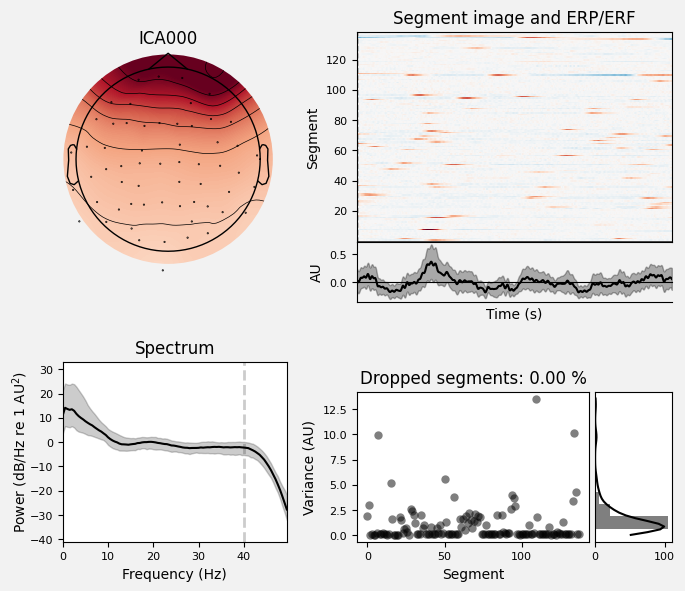

In [42]:
eog_indices, eog_scores = ica.find_bads_eog(raw_art)
print("Components flagged as eye-related:", eog_indices)

# Time course and power spectrum of the flagged components.
if eog_indices:
    fig = ica.plot_properties(raw_art, picks=eog_indices[:2])

The flagged components exhibit a ~1 Hz irregular time course, strong low-frequency power, and a dipolar frontal topography — the textbook signature of blink-related independent components.

Removing these components from the signal proceeds as follows:

```python
ica.exclude = eog_indices
raw_clean = ica.apply(raw_art.copy())
```

A full artifact-correction pipeline (incorporating ICLabel, autoreject, and thorough visual inspection) warrants its own dedicated treatment.

## 11. Further reading and next steps

The material above covers the essential content of Rao chapters 2–4, expressed in executable form. Natural continuations of this notebook include:

### Within the BCI textbook

- **Chapter 5 — Machine Learning.** Construction of a classifier that discriminates auditory from visual trials using the evoked responses computed above; a good entry point is `mne.decoding` (LDA, CSP, regularised covariance classifiers).
- **Chapter 6 — Building a BCI.** Identification of which "useful brain response" categories (stimulus-evoked, population activity, imagined motor activity) can be decoded from this or similar data.
- **Chapters 7–9 — Invasive, semi-invasive, and non-invasive BCIs.** Chapter 9 is the direct continuation of this notebook; motor-imagery BCIs (ERD/ERS in the μ and β bands) are the natural next topic.

### MNE tutorials of immediate relevance

- `tutorials/preprocessing/40_artifact_correction_ica.py` — a fuller ICA pipeline;
- `tutorials/epochs/20_visualize_epochs.py` — additional epoch visualisation methods;
- `tutorials/stats-source/` — statistics on ERPs across subjects;
- `tutorials/machine-learning/` — decoding of brain states;
- `tutorials/inverse/` — source localisation (estimating the cortical origin of the signal).

### Low-cost hardware options

For the transition from sample data to custom recordings, several accessible options exist:

- **OpenBCI Cyton (8 channels)** or **Ganglion (4 channels)** — the open-hardware standard, streaming via LSL, with clean integration into MNE through `mne-lsl`;
- **Muse 2** — a consumer headband with 4 channels, suitable for α/β detection and neurofeedback, but spatially limited;
- **Emotiv** and **Neurosity Crown** — higher channel counts at reduced openness.

For any of these platforms, the analysis code presented above remains applicable without modification: a `Raw` object is loaded, filtered, epoched, and averaged.

## 12. Summary — reference pipeline

```python
import mne
from mne.datasets import sample

# 1. Load
raw = mne.io.read_raw_fif(path, preload=True)

# 2. Inspect
raw.info
raw.plot()
raw.plot_sensors()
raw.compute_psd().plot()

# 3. Clean
raw.filter(l_freq=1.0, h_freq=40.0)
raw.notch_filter(freqs=[50])       # [60] in North America
ica = mne.preprocessing.ICA(n_components=15).fit(raw)
ica.exclude = ica.find_bads_eog(raw)[0]
raw_clean = ica.apply(raw.copy())

# 4. Epoch
events = mne.find_events(raw_clean, stim_channel="STI 014")
epochs = mne.Epochs(raw_clean, events, event_id, tmin=-0.2, tmax=0.5,
                    baseline=(None, 0), preload=True)

# 5. Average
evoked = epochs["condition"].average()
evoked.plot()
evoked.plot_topomap(times=[0.1, 0.2, 0.3])

# 6. Compare
mne.viz.plot_compare_evokeds({"A": evoked_a, "B": evoked_b})
```

This sequence covers approximately 90% of routine M/EEG analysis. Extensions to the above pattern address domain-specific requirements but do not alter its overall structure.